In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from Sql_func import read_query

In [3]:
query = 'show tables;'
read_query(query)

,Tables_in_swiftmarket
0,categories
1,customers
2,employees
3,salesdata
4,subcategories
5,suppliers


In [4]:
# import sys
# !{sys.exectitable} -m pip install matplotlib

In [5]:
query = 'select * from customers limit 5'
read_query(query)

,CustomerID,FirstName,LastName,Email,Phone,Address,State
0,C-2023-100-1,Mahika,Sunder,MahikaSunder_11@zmail.com,03412176590,"H.No. 155, Chana",Assam
1,C-2023-100-10,Zeeshan,Vasa,ZeeshanVasa_1@zmail.com,+911151051656,"52, Roy Nagar",Tripura
2,C-2023-100-100,Aaina,Sachdeva,AainaSachdeva_9@zmail.com,+918834507719,"75/92, Kade Marg",Nagaland
3,C-2023-100-101,Shray,Bajwa,ShrayBajwa_11@zmail.com,07410498662,"45, Bora Ganj",Manipur
4,C-2023-100-102,Navya,Dash,NavyaDash_5@zmail.com,+917644200850,70/782\nBahl Road,Kerala


In [6]:
query = 'select * from salesdata limit 5'
read_query(query)

,SaleID,CustomerID,SubcatID,EmployeeID,SaleDate,Quantity,TotalPrice
0,23000,C-2023-100-12,6002,1100,2023-05-02,2,176432.00
1,23001,C-2023-100-141,6029,1115,2023-12-26,2,47172.00
2,23002,C-2023-100-86,6029,1035,2023-03-26,2,47172.00
3,23003,C-2023-100-72,6006,1016,2023-08-01,2,117644.00
4,23004,C-2023-100-142,6030,1067,2023-03-06,5,336560.00


In [7]:
query = 'select * from subcategories limit 5'
read_query(query)

,SubcatID,SubcatName,CategoryID,UnitPrice,SupplierID
0,6001,Smartphones,500100,9599.00,3054
1,6002,Laptops,500100,88216.00,3078
2,6003,Smartwatches,500100,63444.00,3083
3,6004,Wireless headphones,500100,63946.00,3075
4,6005,Portable power banks,500100,34847.00,3069


In [8]:
query = '''
        select t.customerid , c.firstname , t.expenditure
        from
            (
            select sd.customerid , sb.SubcatName, 
                sum(sd.Totalprice) as expenditure
                from salesdata as sd
                join subcategories sb on 
                sd.subcatid = sb.subcatid 
                group by sb.SubcatName, sd.customerid 
                order by expenditure desc
            limit 10 
            )  t 
        
        join customers as c on 
        c.customerid = t.customerid'''


total_expenditure = read_query(query)



In [9]:
total_expenditure

,customerid,firstname,expenditure
0,C-2023-100-88,Dhruv,2635446.00
1,C-2023-100-83,Priyansh,2444754.00
2,C-2023-100-94,Priyansh,2315998.00
3,C-2023-100-56,Elakshi,2162667.00
4,C-2023-100-194,Arhaan,2125975.00
5,C-2023-100-183,Manikya,2068638.00
6,C-2023-100-137,Jiya,1998690.00
7,C-2023-100-181,Tarini,1996550.00
8,C-2023-100-21,Faiyaz,1955897.00
9,C-2023-100-29,Damini,1880580.00


In [10]:
total_expenditure.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customerid   10 non-null     str   
 1   firstname    10 non-null     str   
 2   expenditure  10 non-null     object
dtypes: object(1), str(2)
memory usage: 372.0+ bytes


In [11]:
total_expenditure['expenditure'] = total_expenditure['expenditure'].astype(float)

In [12]:
total_expenditure.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customerid   10 non-null     str    
 1   firstname    10 non-null     str    
 2   expenditure  10 non-null     float64
dtypes: float64(1), str(2)
memory usage: 372.0 bytes


In [13]:
customer = total_expenditure['firstname'].values

In [14]:
expend = total_expenditure['expenditure'].values

<BarContainer object of 10 artists>

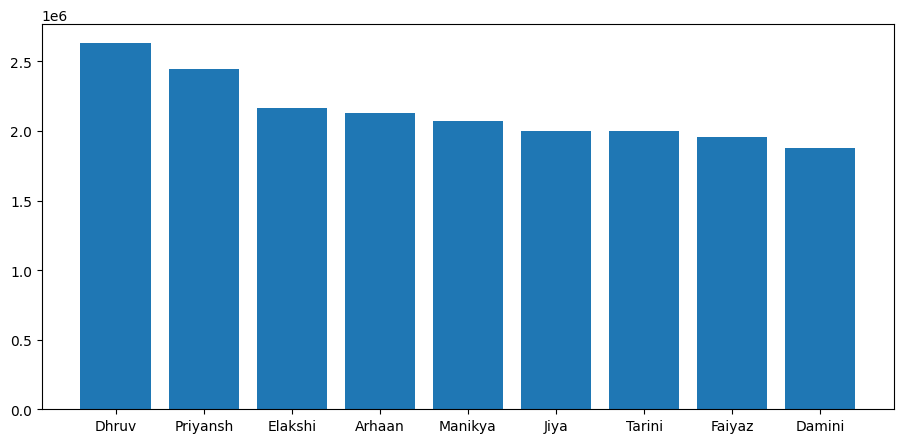

In [15]:
plt.figure(figsize=(11,5))
plt.bar(x = customer , height= expend)




In [16]:
query = 'show tables;'
read_query(query)

,Tables_in_swiftmarket
0,categories
1,customers
2,employees
3,salesdata
4,subcategories
5,suppliers


In [18]:
query = 'select * from suppliers limit 5;'
read_query(query)

,SupplierID,SupplierName,ContactPerson,Email,Phone,Address,State
0,3001,Raja-Yogi,Tejas Magar,kkala@rattan-mallick.com,+914438239269,"H.No. 465, Chadha Nagar\nAmroha 898232",Rajasthan
1,3002,"Sridhar, Sidhu and Maharaj",Trisha Tella,darshitsuri@raj.info,6329450696,"H.No. 56\nBath, Patna-426289",Assam
2,3003,"Sahota, Khurana and Kumar",Veer Rajagopal,chowdhuryazad@sami-choudhary.info,+911453437713,"H.No. 406\nDixit Road, Barasat 755279",Uttarakhand
3,3004,Agate-Kalita,Armaan Mammen,ehsaanbadami@chacko-sethi.com,+911025312767,"96, Banerjee Path\nMalda-102338",Bihar
4,3005,"Suresh, Hans and Borra",Kabir Loyal,tganesan@ramakrishnan.com,08649622797,"66/317, Brar Road\nMaheshtala-954181",Jharkhand


In [19]:
query = 'select * from employees limit 5;'
read_query(query)

,EmployeeID,FirstName,LastName,Email,Phone,Address,State,HireDate,Department,Salary
0,1001,Fateh,Roy,fname.lname@swiftm.org,+915182804115,H.No. 99\nMalhotra Circle,Bihar,2019-04-23,Marketing,54050.23
1,1002,Chirag,Balan,fname.lname@swiftm.org,06425511681,"91, Kalita",Chhattisgarh,2016-03-31,Legal,57094.43
2,1003,Dhanush,Lata,fname.lname@swiftm.org,+916818532690,H.No. 234\nLall,Bihar,2013-05-05,Accounts,40736.84
3,1004,Anika,Batta,fname.lname@swiftm.org,+914753170991,189\nThaker Zila,Arunachal Pradesh,2010-09-19,Legal,20412.30
4,1005,Keya,Dixit,fname.lname@swiftm.org,4791301806,"H.No. 42, Sachar",Manipur,2011-10-23,Logistics,49586.07


In [37]:
query = """ select fe.firstname, fe.lastname, fe.salary , fe.department
            from
            (select *,
            rank() over(partition by department order by salary desc) as ranked
            from employees
            limit 50 ) fe
           
            where fe.ranked <=1
         """

read_query(query)

,firstname,lastname,salary,department
0,Madhup,Vig,58979.77,Accounts
1,Kanav,Wali,59183.76,Analyst
2,Azad,Chana,56174.11,Engineering
3,Rhea,Handa,56513.16,HR Admin


In [89]:
query = """ select fe.firstname, fe.lastname, fe.total_salary , fe.department, fe.ranked
            from
            (select *,
            sum(salary) over(partition by department) as total_salary,
            rank() over(partition by department order by salary desc) as ranked
            from employees
            limit 50) fe

            where fe.ranked   < 2
         """

emp_salary = read_query(query)
emp_salary

,firstname,lastname,total_salary,department,ranked
0,Madhup,Vig,445848.85,Accounts,1
1,Kanav,Wali,732044.77,Analyst,1
2,Azad,Chana,393266.08,Engineering,1
3,Rhea,Handa,482618.09,HR Admin,1


In [90]:
dept_name = emp_salary['department'].values


In [91]:
emp_salary = emp_salary['total_salary'].values

In [96]:
# emp_salary['total_salary']  = emp_salary['total_salary'].astype(float)

In [97]:
# emp_salary.info()

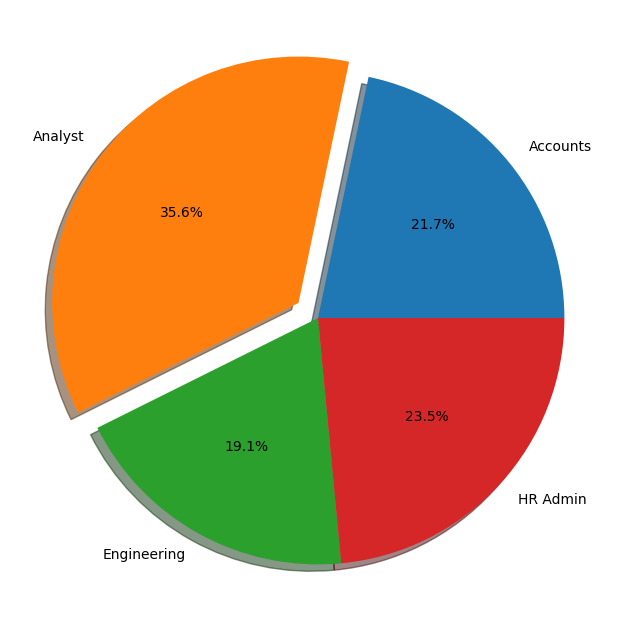

In [ ]:
plt.figure(figsize=(11,8))
plt.pie(x = emp_salary  ,
         labels = dept_name , 
         autopct= '%1.1f%%',
         explode = [0,0.1,0,0], 
         shadow=True)
plt.show()

In [95]:
# query = """
# SELECT 
#     fe.firstname, 
#     fe.lastname, 
#     fe.salary, 
#     fe.department, 
#     fe.total_salary,
#     fe.ranked
# FROM
# (
#     SELECT *,
#            SUM(salary) OVER(PARTITION BY department) AS total_salary,
#            RANK() OVER(PARTITION BY department ORDER BY salary DESC) AS ranked
#     FROM employees
#     LIMIT 50
# ) fe
# """

# read_query(query)